In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
tf.config.optimizer.set_jit(True)  # Enable XLA

E0000 00:00:1745956125.427270     560 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745956125.444935     560 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import numpy as np
from glob import glob

In [3]:
from tensorflow.keras import layers, models, initializers, regularizers
from keras.callbacks import LearningRateScheduler, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay
import gc

from tensorflow.keras.mixed_precision import set_global_policy
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)
print("Mixed precision enabled with policy:", policy.name)

Mixed precision enabled with policy: mixed_float16


In [4]:
import utils_glob_stats

# Load global statistics with utils
label_frequencies = utils_glob_stats.load_class_weights(segment_length=10)

global_stats = utils_glob_stats.load_global_stats(segment_length=10)

time_axis_stats = utils_glob_stats.load_time_axis_stats(segment_length=10)

I0000 00:00:1745956131.515602     560 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [5]:
total = label_frequencies['total_examples']
class_weights_combined = label_frequencies['combined_weights_numpy']
class_weights_tf = tf.constant(class_weights_combined, dtype=tf.float32) #convert to tensor for focal loss

mean_global = global_stats['mean']
std_global = global_stats['std']

T_FIXED = time_axis_stats['mean']

print('Total training examples, ', total)
print('Spectrogram mean, ', mean_global)
print('Spectrogram std, ', std_global)
print('Mean time axis val, ', T_FIXED)
print('Class weights, ', class_weights_combined)

Total training examples,  70078
Spectrogram mean,  -38.622053581065884
Spectrogram std,  13.92796650578306
Mean time axis val,  432
Class weights,  [[0.19714070306078363, 0.34159062547412294], [0.14197785989591272, 1.0453162289922056], [0.1832123734588971, 0.3934137249441564], [0.1594014994329912, 0.5791953186604605], [0.18091928621213352, 0.4044205909323905], [0.14573351300749096, 0.878610832409367], [0.1613689116468689, 0.554625174081637], [0.1319795998292657, 2.3636670258058103]]


### Helper functions to load the dataset

In [6]:
def get_feature_description():
    feature_description = {
        'mel': tf.io.FixedLenFeature([], tf.string),
        'labels': tf.io.VarLenFeature(tf.int64),
        'song': tf.io.FixedLenFeature([], tf.string),
        'segment_idx': tf.io.FixedLenFeature([], tf.int64),
        'total_segments': tf.io.FixedLenFeature([], tf.int64),
    }
    return feature_description

In [7]:
def get_labels(file):
    dataset = tf.data.TFRecordDataset(file)
    feature_description = {
        'labels': tf.io.VarLenFeature(tf.int64)
    }
    example = next(iter(dataset))

    parsed = tf.io.parse_single_example(example, feature_description)
    labels = tf.sparse.to_dense(parsed['labels']).numpy()
    return labels

In [8]:
def get_song_id(file):
    ds = tf.data.TFRecordDataset(file)
    feat = {'song': tf.io.FixedLenFeature([], tf.string)}
    raw = next(iter(ds))
    parsed = tf.io.parse_single_example(raw, feat)
    return parsed['song'].numpy().decode('utf-8')

In [9]:
def parse_tfrecord_fn(example):
    feature_description = get_feature_description()
    example = tf.io.parse_single_example(example, feature_description)
    
    # Directly parse the float32 tensor
    mel_spec = tf.io.parse_tensor(example['mel'], out_type=tf.float32)
    
    current_shape = tf.shape(mel_spec)
    
    if tf.rank(mel_spec) != 2:
        # If not a 2D tensor, reshape it to [96, ?]
        mel_spec = tf.reshape(mel_spec, [96, -1])
        current_shape = tf.shape(mel_spec)
    
    # Crop or pad the time dimension to 650
    if current_shape[1] > T_FIXED:
        # Crop to [96, 432]
        mel_spec = mel_spec[:, :T_FIXED]
    else:
        # Pad to [96, 432]
        paddings = [[0, 0], [0, T_FIXED - current_shape[1]]]
        mel_spec = tf.pad(mel_spec, paddings, "CONSTANT", constant_values=0)
    
    mel_spec = tf.ensure_shape(mel_spec, [96, T_FIXED])

    # normalization
    mel_spec = (mel_spec - mean_global) / (std_global + 1e-6)
    
    # Add channel dimension for CNN input
    mel_spec = tf.expand_dims(mel_spec, axis=-1)
    
    labels = tf.sparse.to_dense(example['labels'])
    labels = tf.ensure_shape(labels, [8])

    
    return mel_spec, labels

In [48]:
def prepare_dataset(tfrecord_pattern, batch_size=32, is_training=True, aug = 'light'):
    
    dataset = tf.data.Dataset.list_files(tfrecord_pattern, shuffle=is_training)

    dataset = dataset.interleave(
        tf.data.TFRecordDataset,
        cycle_length=6,
        num_parallel_calls=6,
        deterministic= False
    )

    dataset = dataset.map(parse_tfrecord_fn, num_parallel_calls=8)
    #dataset = dataset.cache()
    
    if is_training:
        if aug == 'light':
            aug_fn = make_augment(20,  8,  0.1,  0.005,  20)
        elif aug == 'normal':
            aug_fn = make_augment(40, 16, 0.3, 0.02, 40)
        else:  #strong
            aug_fn = make_augment(60, 16, 0.4, 0.1, 60)

        dataset = dataset.map(aug_fn, num_parallel_calls=6)
        dataset = dataset.shuffle(50000, reshuffle_each_iteration=True)
        
    dataset = dataset.batch(batch_size, drop_remainder=is_training)

    dataset = dataset.map(
        lambda x, y: (x, {'aux_out': y, 'binary_output': y}),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    if is_training:
        dataset = dataset.repeat()
    
    dataset = dataset.prefetch(1)
    
    return dataset

### Augmentation functions

In [11]:
def make_augment(max_frames, max_bins, gain, noise_std, crop):
    def augment(m, labels):
        orig_e = tf.reduce_mean(tf.square(m))
        T = tf.shape(m)[1]

        # — Time Mask —
        if max_frames > 0:
            def do_time_mask():
                mm = time_mask(m, max_frames)
                e = tf.reduce_mean(tf.square(mm))
                return mm * tf.sqrt(orig_e/(e + 1e-8))
            m = tf.cond(
                tf.random.uniform([]) < 0.8,
                true_fn=do_time_mask,
                false_fn=lambda: m
            )

        # — Freq Mask —
        if max_bins > 0:
            def do_freq_mask():
                mm = freq_mask(m, max_bins)
                e = tf.reduce_mean(tf.square(mm))
                return mm * tf.sqrt(orig_e/(e + 1e-8))
            m = tf.cond(
                tf.random.uniform([]) < 0.8,
                true_fn=do_freq_mask,
                false_fn=lambda: m
            )

        # — Random Gain —
        if gain > 0:
            def do_gain():
                return random_gain(m, 1.0 - gain, 1.0 + gain)
            m = tf.cond(
                tf.random.uniform([]) < 0.7,
                true_fn=do_gain,
                false_fn=lambda: m
            )

        # — Time Shift —
        m = tf.cond(
            tf.random.uniform([]) < 0.6,
            true_fn=lambda: random_time_shift(m, max_shift=10),
            false_fn=lambda: m
        )

        # — Noise + Renorm —
        if noise_std > 0:
            def do_noise():
                std = tf.random.uniform([], noise_std/2, noise_std)
                mm = m + tf.random.normal(tf.shape(m), 0., std, dtype=m.dtype)
                e = tf.reduce_mean(tf.square(mm))
                return mm * tf.sqrt(orig_e/(e + 1e-8))
            m = tf.cond(
                tf.random.uniform([]) < 1.0,
                true_fn=do_noise,
                false_fn=lambda: m
            )

        # — Time Crop + Renorm + Pad —
        if crop > 0:
            def do_crop():
                win = tf.random.uniform([], T - crop, T, dtype=tf.int32)
                start = tf.random.uniform([], 0, T - win, dtype=tf.int32)
                cm = m[:, start:start + win, :]
                e = tf.reduce_mean(tf.square(cm))
                cm = cm * tf.sqrt(orig_e/(e + 1e-8))
                return tf.pad(cm, [[0,0], [0, T - win], [0,0]])
            m = tf.cond(
                tf.random.uniform([]) < 0.45,
                true_fn=do_crop,
                false_fn=lambda: m
            )

        m = tf.ensure_shape(m, [96, T_FIXED, 1])
        return m, labels

    return augment

In [12]:
def time_mask(x, max_frames=40):
    """zero-out a random consecutive time stripe"""
    T  = tf.shape(x)[1]
    t  = tf.random.uniform([], 0, max_frames, tf.int32)
    t0 = tf.random.uniform([], 0, T - t,      tf.int32)
    zeros = tf.zeros_like(x[:, t0:t0+t, :])
    return tf.concat([x[:, :t0, :], zeros, x[:, t0+t:, :]], axis=1)

In [13]:
def freq_mask(x, max_bins=16):
    """zero-out a random consecutive mel-bin stripe"""
    F  = tf.shape(x)[0]
    f  = tf.random.uniform([], 0, max_bins, tf.int32)
    f0 = tf.random.uniform([], 0, F - f,      tf.int32)
    zeros = tf.zeros_like(x[f0:f0+f, :, :])
    return tf.concat([x[:f0, :, :], zeros, x[f0+f:, :, :]], axis=0)

In [14]:
def random_gain(x, min_gain=0.9, max_gain=1.1):
    '''small volume-like tweaks'''
    gain = tf.random.uniform([], min_gain, max_gain)
    return x * gain

In [15]:
def random_time_shift(x, max_shift=10):
    '''roll time axis and wrap it around'''
    shift = tf.random.uniform([], -max_shift, max_shift, dtype=tf.int32)
    return tf.roll(x, shift=shift, axis=1)

### Model Architecture

In [16]:
def residual_block(x, filters, kernel_size=3, stride=1, activation='swish', use_dropout=False, l2=1e-5):
    shortcut = x
    x = layers.Conv2D(filters, kernel_size,
                      strides=stride,
                      padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    
    if use_dropout:
        x = layers.SpatialDropout2D(0.2)(x)
    
    x = layers.Conv2D(filters, kernel_size,
                      strides=1,
                      padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)

    # Adaptive shortcut
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1,
                                 strides=stride,
                                 padding='same',
                                 kernel_initializer='he_normal')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    x = layers.Add()([shortcut, x])
    x = layers.Activation(activation)(x)
    return x

In [17]:
from tensorflow.keras.callbacks import Callback
from tensorflow.keras import backend as K

class AuxLossDisabler(tf.keras.callbacks.Callback):
    def __init__(self, aux_weight_var, epoch_to_disable=10):
        super().__init__()
        self.aux_weight_var = aux_weight_var
        self.epoch_to_disable = epoch_to_disable

    def on_epoch_begin(self, epoch, logs=None):
        if epoch >= self.epoch_to_disable:
            self.aux_weight_var.assign(0.0)
            print(f"\nEpoch {epoch}: Auxiliary loss disabled")

In [18]:
def build_encoder(inp_shape=(96,T_FIXED,1)):
    inputs = layers.Input(shape=inp_shape)
    
    x = layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    
    x = layers.MaxPooling2D((2, 4))(x)
    
    x = residual_block(x, 64, use_dropout=True)
    x = layers.MaxPooling2D((2, 3))(x)
    
    return models.Model(inputs, x, name='encoder')

In [19]:
from tensorflow.keras.layers import GlobalAvgPool2D, Dense, Multiply, Reshape

# SE block with post-multiply batch-norm for stability
def se_block(x, r=16):
    c = x.shape[-1]
    s = layers.GlobalAveragePooling2D()(x)
    s = layers.Dense(c//r, activation='relu')(s)
    s = layers.Dense(c, activation='sigmoid')(s)
    s = layers.Reshape((1,1,c))(s)
    x = layers.Multiply()([x, s])
    x = layers.BatchNormalization()(x)
    return x

In [20]:
from tensorflow.keras.layers import MultiHeadAttention

In [21]:
# Inception Block with original implementation (no bottlenecks)
def InceptionBlock(x, growth_rate=32):
    # Direct 1x1 convolution
    branch1x1 = layers.Conv2D(growth_rate, (1, 1), padding='same', activation='relu')(x)
    
    # Direct 3x3 convolution (no bottleneck)
    branch3x3 = layers.Conv2D(growth_rate, (3, 3), padding='same', activation='relu')(x)
    
    # Direct 5x5 convolution (no bottleneck)
    branch5x5 = layers.Conv2D(growth_rate, (5, 5), padding='same', activation='relu')(x)
    
    # Pool projection
    branch_pool = layers.MaxPooling2D((3, 3), strides=1, padding='same')(x)
    branch_pool = layers.Conv2D(growth_rate, (1, 1), padding='same', activation='relu')(branch_pool)
    
    # Concatenate all branches
    output = layers.Concatenate(axis=-1)([branch1x1, branch3x3, branch5x5, branch_pool])
    return output

# Broadcast Module with dense connections (original implementation)
def BroadcastModule(x, num_blocks=3, growth_rate=32):
    outputs = [x]
    for i in range(num_blocks):
        concat_features = layers.Concatenate(axis=-1)(outputs)
        x = InceptionBlock(concat_features, growth_rate)
        outputs.append(x)
    return layers.Concatenate(axis=-1)(outputs)

# Full BBNN Model restored to original capacity but with correct dimension handling
def one_model(input_shape=(96, 432, 1), num_classes=8):
    inputs = layers.Input(shape=input_shape)
    
    # Shallow Layer - reduce time domain, preserve frequency
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D(pool_size=(1, 4))(x)  # Reduce time dimension (432 -> 108)
    
    # Broadcast Module (BM) with 3 blocks - original implementation
    x = BroadcastModule(x, num_blocks=2, growth_rate=32)

    # Transition Layer 1
    x = layers.Conv2D(64, (1, 1), strides = (2, 2), padding='same', activation='relu')(x)
    #x = layers.MaxPooling2D(pool_size=(2, 2))(x) # Reduce dimensions (96, 108 -> 48, 54)

    # Broadcast Module 2 (BM) with 2 blocks
    x = BroadcastModule(x, num_blocks=2, growth_rate=32)
    
    # Transition Layer 2
    x = layers.Conv2D(64, (1, 1), padding='same', activation='relu')(x)
    x = layers.AveragePooling2D(pool_size=(2, 2))(x)  # 24, 27
    
    # Global Average Pooling + Softmax
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='sigmoid')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

In [22]:
# Example usage
model = one_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 432,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 96, 432,   │          0 │ input_layer[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 432,   │        320 │ cast[0][0]        │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 96, 108,   │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96, 108,   │          0 │ max_pooling2d[0]… │
│ (Concatenate)       │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 96, 108,   │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 96, 108,   │      1,056 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 96, 108,   │      9,248 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 96, 108,   │     25,632 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 96, 108,   │      1,056 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96, 108,   │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │ 128)              │            │ conv2d_2[0][0],   │
│                     │                   │            │ conv2d_3[0][0],   │
│                     │                   │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 96, 108,   │          0 │ max_pooling2d[0]… │
│ (Concatenate)       │ 160)              │            │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 96, 108,   │          0 │ concatenate_2[0]… │
│ (MaxPooling2D)      │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 96, 108,   │      5,152 │ concatenate_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 96, 108,   │     46,112 │ concatenate_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 96, 108,   │    128,032 │ concatenate_2[0]… │
│                     │ 32)               │            │                 

 Total params: 556,488 (2.12 MB)

 Trainable params: 556,488 (2.12 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
def build_finetune_model(pretrained_encoder, class_weights):
    inp = pretrained_encoder.input
    x = pretrained_encoder.output

    # Separable blocks: freq → time
    for kernel, filters in [((7,1), 128),
                            ((1, 5), 128)]:
        res = x
        # project if channel mismatch
        if res.shape[-1] != filters:
            res = layers.Conv2D(
                filters, (1,1),
                padding='same',
                use_bias=False
            )(res)
            res = layers.BatchNormalization()(res)

        x = layers.Conv2D(
            filters,
            kernel,
            padding='same',
            use_bias=False,
            kernel_regularizer=regularizers.l2(1e-5)
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('swish')(x)

        x = layers.Add()([x, res])
        x = layers.Dropout(0.25)(x)

    # down scaling
    x = residual_block(x, 192, stride=(2,2), l2=1e-5)
    x = layers.Dropout(0.25)(x)

    # Dilated convs on time axis
    for d in [1, 2, 4, 8]:
        res = x
        # channels already 128, no projection needed
        x = layers.Conv2D(
            192,
            (1, 3),
            padding='same',
            dilation_rate=(1, d),
            use_bias=False,
            kernel_regularizer=regularizers.l2(1e-5)
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('swish')(x)

        x = layers.Add()([x, res])
        x = layers.Dropout(0.25)(x)

    # Further downsample + feature concat
    x = residual_block(x, 256, stride=(2,2), l2=1e-5)

    # SE block
    #x = se_block(x)
    
    gap = layers.GlobalAveragePooling2D()(x)
    gmp = layers.GlobalMaxPooling2D()(x)
    
    features = layers.Concatenate()([gap, gmp])

    # Auxiliary head
    aux = layers.Dense(128,
                       activation='swish',
                       kernel_regularizer=regularizers.l2(5e-4)
                      )(features)
    aux = layers.Dropout(0.35)(aux)
    aux_out = layers.Dense(8, activation='sigmoid', name='aux_out')(aux)

    # 6) Main classification head
    y = layers.Dense(512, use_bias=False,
                     kernel_regularizer=regularizers.l2(5e-5))(features)
    y = layers.BatchNormalization()(y)
    y = layers.Activation('swish')(y)
    y = layers.Dropout(0.4)(y)

    y = layers.Dense(256, use_bias=False,
                     kernel_regularizer=regularizers.l2(1e-5))(features)
    y = layers.BatchNormalization()(y)
    y = layers.Activation('swish')(y)
    y = layers.Dropout(0.1)(y)
    
    # bias init from class weights
    init_bias = np.log(class_weights[:,1] / class_weights[:,0])
    binary_output = layers.Dense(
        8,
        activation='sigmoid',
        kernel_initializer='he_normal',
        bias_initializer=initializers.Constant(init_bias),
        kernel_regularizer=regularizers.l2(1e-5),
        name='binary_output'
    )(y)

    return models.Model(
        inputs=inp,
        outputs=[aux_out, binary_output],
        name='finetune_sepconv_head'
    )

### Custom loss functions

In [25]:
class DynamicLossWeightDecay(tf.keras.callbacks.Callback):
    def __init__(self, aux_weight_var, initial_aux_weight=0.3, decay_rate=0.9, min_aux_weight=0.05):
        super().__init__()
        self.aux_weight_var = aux_weight_var
        self.initial_aux_weight = initial_aux_weight
        self.decay_rate = decay_rate
        self.min_aux_weight = min_aux_weight
        self.current_aux_weight = initial_aux_weight

    def on_epoch_end(self, epoch, logs=None):
        # Decay the auxiliary weight
        self.current_aux_weight = max(self.min_aux_weight, 
                                      self.current_aux_weight * self.decay_rate)
        # Update the mutable weight variable
        self.aux_weight_var.assign(self.current_aux_weight)
        if epoch < 20:
            print(f"\nAux weight decayed to: {self.current_aux_weight:.4f}")

In [26]:
@tf.function
def custom_cosine_similarity(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=y_pred.dtype)
    dot_product = tf.reduce_sum(y_true * y_pred, axis=-1)
    norm_true = tf.sqrt(tf.reduce_sum(y_true ** 2, axis=-1))
    norm_pred = tf.sqrt(tf.reduce_sum(y_pred ** 2, axis=-1))
    # If norm_pred is too small, set similarity to 0 to avoid NaN
    cosine_sim = tf.where(norm_pred > 1e-8, dot_product / (norm_true * norm_pred + 1e-8), 0.0)
    return 1.0 -cosine_sim  # minimize loss

In [27]:
@tf.function
def focal_sparsity_entropy_loss(
    y_true, y_pred, gamma=1.0, class_weights=None, 
    sparsity_weight=0.01, entropy_weight=0.005, target_mean_activation=0.2
):
    dtype = y_pred.dtype
    y_true = tf.cast(y_true, dtype=dtype)
    
    # Create smoothed version for BCE loss calculation
    smooth_factor = 0.1
    y_true_smoothed = y_true * (1 - smooth_factor) + smooth_factor * 0.05
    
    # Clip predictions for numerical stability
    y_pred = tf.clip_by_value(y_pred, 1e-6, 1.0 - 1e-6)
    
    # Binary cross-entropy with smoothed labels
    bce = -y_true_smoothed * tf.math.log(y_pred) - (1 - y_true_smoothed) * tf.math.log(1 - y_pred)
    
    # Focal weighting with original labels
    p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    focal_weight = tf.pow(1 - p_t, gamma)
    focal_bce = focal_weight * bce
    
    if class_weights is not None:
        weights_0 = tf.cast(class_weights[:, 0][None, :], dtype=dtype)
        weights_1 = tf.cast(class_weights[:, 1][None, :], dtype=dtype)
        weights = tf.where(y_true == 1.0, weights_1, weights_0)
        focal_bce = focal_bce * weights
        
    focal_loss = tf.reduce_mean(focal_bce, axis=-1)
    
    # Sparsity penalty - penalize if average activation differs from target
    mean_activation = tf.reduce_mean(y_pred, axis=-1)
    sparsity_penalty = tf.square(mean_activation - target_mean_activation)
    
    # Entropy penalty - penalize uncertain predictions
    entropy = -y_pred * tf.math.log(y_pred) - (1 - y_pred) * tf.math.log(1 - y_pred)
    entropy_penalty = tf.reduce_mean(entropy, axis=-1)
    
    return focal_loss + sparsity_weight * sparsity_penalty + entropy_weight * entropy_penalty

In [28]:
from sklearn.model_selection import train_test_split
from collections import Counter

In [29]:
batch_size = 64

In [30]:
files_dir = tf.io.gfile.glob(
    "/home/georgios/Music Analysis/dataset_creation/tfrecord_dataset_10s/train/*.tfrecord"
)
labels = np.array([get_labels(f) for f in files_dir])
all_files = np.array(files_dir)

In [31]:
song_ids = [get_song_id(f) for f in all_files]

In [32]:
# map song_id to indices
song_to_idxs = {}
for i, sid in enumerate(song_ids):
    song_to_idxs.setdefault(sid, []).append(i)

In [33]:
# compute initial val_indices by label coverage
n_total = len(all_files)
val_split = 0.10
n_each = int(n_total * (val_split/2))

In [34]:
start = np.arange(n_each)
end   = np.arange(n_total-n_each, n_total)
val_set = set(np.concatenate([start, end]))

In [35]:
for g in range(labels.shape[1]):
    vl = labels[list(val_set)]
    if vl[:,g].sum() == 0:
        for i in range(n_total):
            if i not in val_set and labels[i, g] == 1:
                val_set.add(i)
                break

In [36]:
# expand to include all segments of each chosen song
expanded = set()
for i in val_set:
    sid = song_ids[i]
    expanded.update(song_to_idxs[sid])

In [37]:
val_indices = np.array(sorted(expanded))
train_indices = np.array([i for i in range(n_total) if i not in val_indices])

In [38]:
# final splits
train_files = all_files[train_indices]
val_files   = all_files[val_indices]

print("Train samples:", len(train_files))
print("Val   samples:", len(val_files))

Train samples: 63
Val   samples: 8


In [39]:
class_weights_np = class_weights_tf.numpy() # Convert tf.Tensor to NumPy

# Double weights for POP (index 5) and ENALLAKTIKO (index 6) positive class (column 1)
class_weights_np[5, 1] *= 5.0  # POP
class_weights_np[6, 1] *= 5.0  # ENALLAKTIKO

# Convert back to tf.Tensor
class_weights_tf = tf.constant(class_weights_np, dtype=tf.float32)

print(class_weights_tf)

tf.Tensor(
[[0.19714071 0.3415906 ]
 [0.14197786 1.0453162 ]
 [0.18321237 0.39341372]
 [0.1594015  0.5791953 ]
 [0.18091929 0.40442058]
 [0.14573352 4.393054  ]
 [0.1613689  2.7731256 ]
 [0.1319796  2.363667  ]], shape=(8, 2), dtype=float32)


In [40]:
train_dataset = prepare_dataset(train_files, batch_size= batch_size, aug='light')#start with light augmentation

In [51]:
val_dataset = prepare_dataset(val_files, batch_size= batch_size, is_training=False)

In [52]:
examples_per_file = total / len(train_files)

orig_files_count = len(train_files)

estimated_total_examples = orig_files_count * examples_per_file
steps_per_epoch = int(estimated_total_examples // batch_size if estimated_total_examples
                      % batch_size == 0 else (estimated_total_examples // batch_size) + 1)
print(f"Total training examples: {total}")
print(f"Original files: {orig_files_count}")
print(f"Steps per epoch: {steps_per_epoch:.0f}")

Total training examples: 70078
Original files: 63
Steps per epoch: 1095


### Loss initiators, optimizer and learning rate schedule

In [52]:
binary_output_weight = tf.Variable(1.0, dtype=tf.float32, trainable=False)
aux_out_weight = tf.Variable(0.4, dtype=tf.float32, trainable=False)

In [43]:
@tf.function
def focal_sparsity_entropy_loss_with_weights(y_true, y_pred):
    return focal_sparsity_entropy_loss(
        y_true,
        y_pred,
        gamma=2.0,                   # focus more on mis-classified samples
        class_weights=class_weights_tf,
        sparsity_weight=0.03,        # light sparsity penalty
        entropy_weight=0.01,        # discourage over-confidence
        target_mean_activation=0.2  # expect ~2 active labels out of 8
    )

In [44]:
def binary_output_loss(y_true, y_pred):
    base_loss = focal_sparsity_entropy_loss_with_weights(y_true, y_pred)
    return tf.cast(binary_output_weight, base_loss.dtype) * base_loss

def aux_out_loss(y_true, y_pred):
    base_loss = custom_cosine_similarity(y_true, y_pred)
    return tf.cast(aux_out_weight, base_loss.dtype) * base_loss

### Modular functions for compile and callbacks

In [44]:
def compile_model(model, optimizer):
    model.compile(
        optimizer=optimizer,
        loss={'binary_output': focal_sparsity_entropy_loss_with_weights,
             'aux_out': aux_out_loss},
        loss_weights={'binary_output': 1.0, 'aux_out':1.0},
        metrics={'binary_output': [
                tf.keras.metrics.BinaryAccuracy(),
                tf.keras.metrics.F1Score(threshold=0.5, average='micro', name='f1_micro'),
                tf.keras.metrics.F1Score(threshold=0.5, average='macro', name='f1_macro')]}
    )

In [44]:
def get_callbacks(save_path, min_lr=5e-7, epoch_to_disable_aux=10, patience_early = 5, lr_warmup=False):
    dynamic_loss_decay = DynamicLossWeightDecay(
    aux_weight_var=aux_out_weight,
    initial_aux_weight=0.4,
    decay_rate=0.8,
    min_aux_weight=0.05
    )
    
    # Instantiate the aux loss disabler
    aux_loss_disabler = AuxLossDisabler(
        aux_weight_var=aux_out_weight,
        epoch_to_disable= epoch_to_disable_aux
    )
    
    callbacks = [
        aux_loss_disabler,
        dynamic_loss_decay,
        EarlyStopping(
            monitor='val_binary_output_f1_macro',
            patience=5,
            restore_best_weights=True,
            mode = 'max',
            verbose=1
        ),
        ModelCheckpoint(
            filepath='saved_models/'+save_path,
            monitor='val_binary_output_f1_macro',
            mode = 'max',
            save_best_only=True,
            verbose=1
        )
    ]
    if lr_warmup:
        lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lr_schedule_with_warmup)
        callbacks.append(lr_scheduler)
    else:
        callbacks.append(tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.1,
                patience=2,
                min_lr=5e-7,
                verbose=1)
                )
    return callbacks

In [49]:
model.compile(
        optimizer=optimizer,
        loss=focal_sparsity_entropy_loss_with_weights,
        metrics=[
                tf.keras.metrics.BinaryAccuracy(),
                tf.keras.metrics.F1Score(threshold=0.5, average='micro', name='f1_micro'),
                tf.keras.metrics.F1Score(threshold=0.5, average='macro', name='f1_macro')]
    )

In [50]:
callbacks = [
    EarlyStopping(
            monitor='val_f1_macro',
            patience=5,
            restore_best_weights=True,
            mode = 'max',
            verbose=1
        ),
    ModelCheckpoint(
            filepath='best_BBNN.keras',
            monitor='val_f1_macro',
            mode = 'max',
            save_best_only=True,
            verbose=1
        ),
    tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.1,
                patience=2,
                min_lr=5e-7,
                verbose=1
    )
]

### 1st Part: Frozen Encoder backbone -> Train deeper layers

In [48]:
#prevent large random updates on untrained head
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0, weight_decay=1e-4)

In [46]:
# Get saved pretrained weights from contrastive training
pretrained_weights_path = 'contrastive_weights/latest_encoder_checkpoint.weights.h5'

In [46]:
inp_shape = 96,432,1

In [47]:
one_model = build_full_model(class_weights_tf)

In [47]:
# Build the model
pretrained_encoder = build_encoder(inp_shape=(96, T_FIXED, 1))
pretrained_encoder.load_weights(pretrained_weights_path)

model = build_finetune_model(pretrained_encoder, class_weights_tf)

In [48]:
#Non trainable for first few epochs, freeze entire encoder
pretrained_encoder.trainable = False

In [49]:
compile_model(model, optimizer)
callbacks = get_callbacks('saved_models/CNN_Att_model_Frozen_Encoder.keras', epoch_to_disable_aux=15, patience_early=5, min_lr=1e-4)

In [48]:
compile_model(one_model, optimizer)
callbacks = get_callbacks('saved_models/CNN_model_Try.keras', epoch_to_disable_aux=15, patience_early=10, min_lr=1e-4)

In [52]:
one_model.summary()

Model: "finetune_sepconv_head"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 432,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 96, 432,   │          0 │ input_layer[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 432,   │        288 │ cast[0][0]        │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 96, 432,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 96, 432,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 144,   │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 48, 144,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 144,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 144,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 48, 144,   │          0 │ activation_1[0][… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 144,   │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 144,   │     36,928 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 144,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 144,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 144,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 48, 144,   │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 24, 48,    │          0 │ activation_2[0][

 Total params: 5,466,070 (20.85 MB)

 Trainable params: 1,820,336 (6.94 MB)

 Non-trainable params: 5,056 (19.75 KB)

 Optimizer params: 3,640,678 (13.89 MB)

In [51]:
frozen_layers = 0
for layer in model.layers:
    if not layer.trainable:
        frozen_layers += 1
print(frozen_layers)

16


In [51]:
# Train the model with first few layers frozen
history_frozen = model.fit(
    train_dataset, 
    epochs=50,
    callbacks= callbacks,
    steps_per_epoch = steps_per_epoch,
    validation_data = val_dataset
)

NameError: name 'steps_per_epoch' is not defined

### 2nd Part: Partial Unfreeze - Unfreeze first res block (64) of the model

In [55]:
def lr_schedule_with_warmup(epoch, lr, initial_lr=5e-5): #st epoch: 14. 0.54677
    if epoch < 5:
        return initial_lr * (0.3 + 0.7 * ((epoch + 1) / 5))
    # Cosine decay after warmup
    else:
        decay_epochs = 15
        min_lr = initial_lr * 0.01
        return min_lr + 0.5 * (initial_lr - min_lr) * (1 + np.cos(np.pi * (epoch - 5) / decay_epochs))

In [47]:
train_dataset = prepare_dataset(train_files, batch_size= batch_size, aug='strong')# increase augmentation

In [56]:
# intermediate learning rate to avoid destroying the pretrained contrastive weights too quickly
second_optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, weight_decay=1e-5, clipnorm=0.75)

In [57]:
pretrained_encoder = build_encoder(inp_shape=(96, T_FIXED, 1))
pretrained_encoder.trainable = False

In [58]:
model = build_finetune_model(pretrained_encoder, class_weights_tf)

In [59]:
model.load_weights('saved_models/CNN_Att_model_Frozen_Encoder.keras')

In [60]:
unlock_point = False
for layer in pretrained_encoder.layers:
    if unlock_point:
        layer.trainable = True
    # Unfreeze after the first block has ended
    if layer.name[:-2] == 'max_pooling2d':
        unlock_point = True

In [61]:
# compile the model with partly unfrozen layers
compile_model(model, second_optimizer)
# get standard callbacks with new save path
callbacks = get_callbacks('saved_models/CNN_Att_model_Partly_Frozen.keras', min_lr=8e-6, epoch_to_disable_aux=10, lr_warmup=True)

In [62]:
model.summary()

Model: "finetune_sepconv_head"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 432,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 96, 432,   │          0 │ input_layer_1[0]… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 96, 432,   │        288 │ cast_1[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 432,   │        128 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 96, 432,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 48, 108,   │          0 │ activation_14[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 48, 108,   │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 48, 108,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_1 │ (None, 48, 108,   │          0 │ activation_15[0]… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 48, 108,   │      2,112 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 48, 108,   │     36,928 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 48, 108,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 48, 108,   │          0 │ add_9[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 24, 36,    │          0 │ activation_16[0]

 Total params: 2,189,936 (8.35 MB)

 Trainable params: 2,183,504 (8.33 MB)

 Non-trainable params: 6,432 (25.12 KB)

In [63]:
frozen_layers = 0
for layer in model.layers:
    if not layer.trainable:
        frozen_layers += 1
print(frozen_layers) #5, first conv, bias, batchnorm-gamma+beta, maxpooling

5


In [ ]:
# Fine tune the previously frozen first res block, keep first conv frozen
history_partial = one_model.fit(
    train_dataset, 
    epochs=60,
    callbacks= callbacks,
    steps_per_epoch = steps_per_epoch,
    validation_data = val_dataset
)

Epoch 1/60


### 3d Part: Full unfreeze

In [45]:
# go back to stronger augmentation now that the model has adapted
train_dataset = prepare_dataset(train_files, batch_size= batch_size, aug='strong')# activate stronger augmentation now

In [55]:
def lr_schedule_with_warmup(epoch, lr, initial_lr=5e-5): #st epoch: 14. 0.54677
    if epoch < 5:
        return initial_lr * (0.3 + 0.7 * ((epoch + 1) / 5))
    # Cosine decay after warmup
    else:
        decay_epochs = 15
        min_lr = initial_lr * 0.01
        return min_lr + 0.5 * (initial_lr - min_lr) * (1 + np.cos(np.pi * (epoch - 5) / decay_epochs))

In [56]:
# more conservative learning rate to guard the first few layers from overfitting too quickly.
# still using stronger augmentation to avoid overfitting
third_optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-5, weight_decay=1e-5, clipnorm=0.5) #smaller updates, don't unlearn previous features

In [57]:
pretrained_encoder = build_encoder(inp_shape=(96, T_FIXED, 1))
pretrained_encoder.trainable = True #WAS 0.69 PREVIOUS BEST

In [58]:
model = build_finetune_model(pretrained_encoder, class_weights_tf)

In [59]:
model.summary()

Model: "finetune_sepconv_head"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 432,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 96, 432,   │          0 │ input_layer_1[0]… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 96, 432,   │        288 │ cast_1[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 432,   │        128 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 96, 432,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 48, 108,   │          0 │ activation_14[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 48, 108,   │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 48, 108,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_1 │ (None, 48, 108,   │          0 │ activation_15[0]… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 48, 108,   │      2,112 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 48, 108,   │     36,928 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 48, 108,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 48, 108,   │          0 │ add_9[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 24, 36,    │          0 │ activation_16[0]

 Total params: 2,189,936 (8.35 MB)

 Trainable params: 2,183,856 (8.33 MB)

 Non-trainable params: 6,080 (23.75 KB)

In [60]:
model.load_weights('saved_models/CNN_Att_model_Partly_Frozen.keras')

In [61]:
# compile the model with fully unfrozen layers
compile_model(model, third_optimizer)
# get standard callbacks with new save path
callbacks = get_callbacks('saved_models/CNN_Att_model_Unfrozen.keras', min_lr=5e-7, epoch_to_disable_aux=15, patience_early=10, lr_warmup=True)

In [62]:
frozen_layers = 0
for layer in model.layers:
    if not layer.trainable:
        frozen_layers += 1
print(frozen_layers)

0


In [53]:
# Train full model
history_fine_tuned = model.fit(
    train_dataset, 
    epochs=100,
    callbacks= callbacks,
    steps_per_epoch = steps_per_epoch,
    validation_data = val_dataset
)

Epoch 1/100


I0000 00:00:1745948757.609117   31429 service.cc:148] XLA service 0x7fa8900040a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745948757.609143   31429 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
I0000 00:00:1745948757.614648   31429 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1745948757.645281   31429 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1095/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - binary_accuracy: 0.6046 - f1_macro: 0.3891 - f1_micro: 0.3925 - loss: 0.0586  
Epoch 1: val_f1_macro improved from -inf to 0.51171, saving model to best_BBNN.keras


/home/georgios/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1095/1095 ━━━━━━━━━━━━━━━━━━━━ 207s 135ms/step - binary_accuracy: 0.6047 - f1_macro: 0.3892 - f1_micro: 0.3926 - loss: 0.0586 - val_binary_accuracy: 0.6907 - val_f1_macro: 0.5117 - val_f1_micro: 0.5030 - val_loss: 0.0554 - learning_rate: 0.0010
Epoch 2/100
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - binary_accuracy: 0.6995 - f1_macro: 0.5335 - f1_micro: 0.5233 - loss: 0.0486  
Epoch 2: val_f1_macro did not improve from 0.51171
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 139s 127ms/step - binary_accuracy: 0.6995 - f1_macro: 0.5335 - f1_micro: 0.5233 - loss: 0.0486 - val_binary_accuracy: 0.6652 - val_f1_macro: 0.5008 - val_f1_micro: 0.4661 - val_loss: 0.0626 - learning_rate: 0.0010
Epoch 3/100
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - binary_accuracy: 0.7386 - f1_macro: 0.5768 - f1_micro: 0.5682 - loss: 0.0446  
Epoch 3: val_f1_macro improved from 0.51171 to 0.52582, saving model to best_BBNN.keras

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
1095/1095 ━━━━━━━

### History plots

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
history_dict = history_fine_tuned.history
Accuracy = history_dict['binary_output_binary_accuracy']
Val_Accuracy = history_dict['val_binary_output_binary_accuracy']
plt.figure(num=1, figsize=(15,7))
plt.plot(Accuracy,'bo',label='Training accuracy')
plt.plot(Val_Accuracy,'b',label='Validation accuracy')
plt.title('Final model binary accuracy history')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show();

In [ ]:
# summarize history for loss
plt.plot(history_fine_tuned.history['loss'])
plt.plot(history_fine_tuned.history['val_loss'])
plt.title('Final model loss history')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
# summarize history for f1 micro
plt.plot(history_fine_tuned.history['binary_output_f1_micro'])
plt.plot(history_fine_tuned.history['val_binary_output_f1_micro'])
plt.title('Final model f1 score logs')
plt.ylabel('f1 score')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
# summarize history for f1 macro on final stage
plt.plot(history_fine_tuned.history['binary_output_f1_macro'])
plt.plot(history_fine_tuned.history['val_binary_output_f1_macro'])
plt.title('Unfrozen/fine-tuned f1 score macro logs')
plt.ylabel('f1 score macro')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
# summarize history for f1 macro on partial freeze
plt.plot(history_partial.history['binary_output_f1_macro'])
plt.plot(history_partial.history['val_binary_output_f1_macro'])
plt.title('Partial frozen f1 score macro logs')
plt.ylabel('f1 score macro')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
# summarize history for f1 macro on frozen layers training
plt.plot(history_partial.history['binary_output_f1_macro'])
plt.plot(history_partial.history['val_binary_output_f1_macro'])
plt.title('Frozen phase f1 score macro logs')
plt.ylabel('f1 score macro')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### Testing the model

In [45]:
pretrained_encoder = build_encoder(inp_shape=(96, T_FIXED, 1))

In [47]:
model = build_finetune_model(pretrained_encoder, class_weights_tf)

In [ ]:
saved_models/CNN_Att_model_Unfrozen.keras

In [48]:
model.load_weights("saved_models/CNN_Att_model_Partly_Frozen.keras")

In [49]:
model.summary()

Model: "finetune_sepconv_head"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 432,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 96, 432,   │          0 │ input_layer[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 432,   │        288 │ cast[0][0]        │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 96, 432,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 96, 432,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 108,   │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 48, 108,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 108,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 48, 108,   │          0 │ activation_1[0][… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 108,   │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 108,   │     36,928 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 108,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 48, 108,   │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 24, 36,    │          0 │ activation_2[0][

 Total params: 2,189,936 (8.35 MB)

 Trainable params: 2,183,856 (8.33 MB)

 Non-trainable params: 6,080 (23.75 KB)

In [50]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)
compile_model(model, optimizer)

In [51]:
batch_size = 64

In [52]:
# Prepare test dataset
test_tfrecord_path = "/home/georgios/Music Analysis/dataset_creation/tfrecord_dataset_10s/test/*.tfrecord"
test_files = tf.io.gfile.glob("/home/georgios/Music Analysis/dataset_creation/tfrecord_dataset_10s/test/*.tfrecord")
test_files = np.array(test_files)

In [53]:
test_dataset = prepare_dataset(test_files, batch_size=64, is_training=False)

In [54]:
# Evaluate the model on test data
print("Evaluating model on test data...")
evaluation = model.evaluate(test_dataset)

Evaluating model on test data...


I0000 00:00:1745931705.743963  101210 service.cc:148] XLA service 0x7fb7ac003ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745931705.745229  101210 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
I0000 00:00:1745931705.982028  101210 cuda_dnn.cc:529] Loaded cuDNN version 90300


     19/Unknown 7s 9ms/step - aux_out_loss: 0.2096 - binary_output_binary_accuracy: 0.7757 - binary_output_f1_macro: 0.4490 - binary_output_f1_micro: 0.5690 - binary_output_loss: 0.0811 - loss: 0.3185

I0000 00:00:1745931711.209720  101210 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - aux_out_loss: 0.2083 - binary_output_binary_accuracy: 0.7873 - binary_output_f1_macro: 0.5397 - binary_output_f1_micro: 0.5829 - binary_output_loss: 0.0957 - loss: 0.3318


/home/georgios/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [55]:
all_true_labels = []
all_pred_binary = []
all_pred_proba = []

for x_batch, y_batch in test_dataset:
    # Get raw probabilities
    _, y_pred = model.predict(x_batch, verbose=0)
    # Binary predictions
    y_pred_bin = (y_pred > 0.5).astype(np.float32)
    # True labels
    y_true = y_batch['binary_output'].numpy()
    
    all_true_labels.append(y_true)
    all_pred_binary.append(y_pred_bin)
    all_pred_proba.append(y_pred)

In [56]:
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, 
                             hamming_loss, f1_score, roc_auc_score)

In [57]:
y_true = np.vstack(all_true_labels)
y_pred = np.vstack(all_pred_binary)
y_proba = np.vstack(all_pred_proba)

genre_names = ['LAIKO', 'REMPETIKO', 'ENTEXNO', 'ROCK', 'Mod LAIKO', 'POP', 'ENALLAKTIKO', 'HIPHOP/RNB']

print("\nPer-genre evaluation metrics:")
print("Genre\t\tF1\tPrecision\tRecall\tAccuracy\tAUC")
print("-" * 70)

for i, genre in enumerate(genre_names):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true[:, i], y_pred[:, i], average='binary')
    accuracy = accuracy_score(y_true[:, i], y_pred[:, i])
    auc = roc_auc_score(y_true[:, i], y_proba[:, i])
    
    genre_padded = genre + (" " * (15 - len(genre)))
    print(f"{genre_padded}\t{f1:.3f}\t{precision:.3f}\t\t{recall:.3f}\t{accuracy:.3f}\t\t{auc:.3f}")


Per-genre evaluation metrics:
Genre		F1	Precision	Recall	Accuracy	AUC
----------------------------------------------------------------------
LAIKO          	0.724	0.702		0.747	0.796		0.869
REMPETIKO      	0.674	0.658		0.691	0.926		0.929
ENTEXNO        	0.583	0.515		0.672	0.700		0.776
ROCK           	0.630	0.501		0.847	0.817		0.908
Mod LAIKO      	0.642	0.590		0.703	0.746		0.825
POP            	0.370	0.255		0.674	0.692		0.766
ENALLAKTIKO    	0.485	0.379		0.673	0.707		0.753
HIPHOP/RNB     	0.688	0.757		0.630	0.970		0.910


In [92]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, f1_score, precision_recall_fscore_support, accuracy_score, roc_auc_score
from collections import defaultdict
import time # To measure time if needed

# --- Configuration ---
# !!! CRITICAL: Setting T_FIXED as requested !!!
T_FIXED = 432
BATCH_SIZE = 64
MODEL_WEIGHTS_PATH = "best_CNN_Att_model_Finetuned.keras"
TEST_TFRECORD_PATTERN = "/home/georgios/Music Analysis/dataset_creation/tfrecord_dataset_10s/test/*.tfrecord"
genre_names = ['LAIKO', 'REMPETIKO', 'ENTEXNO', 'ROCK', 'Mod LAIKO', 'POP', 'ENALLAKTIKO', 'HIPHOP/RNB']

# !!! CRITICAL: Define or load your actual mean/std values !!!
# These MUST match the values used during training
# Replace these placeholder values:
print(f"Using T_FIXED = {T_FIXED}")
print(f"Using mean_global = {mean_global}, std_global = {std_global}")

# --- 1. Parsing Function (Adjusted for T_FIXED) ---
# This function is essential to prepare data correctly for the model
def parse_and_preprocess_example(example_proto):
    feature_description = {
        'mel': tf.io.FixedLenFeature([], tf.string),
        'labels': tf.io.VarLenFeature(tf.int64),
        'song': tf.io.FixedLenFeature([], tf.string),
    }
    parsed_features = tf.io.parse_single_example(example_proto, feature_description)
    mel = tf.io.parse_tensor(parsed_features['mel'], out_type=tf.float32)
    # Reshape/Pad/Crop to the specified T_FIXED width
    if tf.rank(mel) != 2: mel = tf.reshape(mel, [96, -1])
    current_shape = tf.shape(mel)
    if current_shape[1] > T_FIXED: mel = mel[:, :T_FIXED] # Crop width
    else: mel = tf.pad(mel, [[0, 0], [0, T_FIXED - current_shape[1]]], "CONSTANT", constant_values=0.0) # Pad width
    mel = tf.ensure_shape(mel, [96, T_FIXED]) # Ensure shape [96, 432]

    # Normalization - Using pre-defined globals
    mel = (mel - mean_global) / (std_global + 1e-6)

    # Add channel dimension: [96, T_FIXED, 1] -> [96, 432, 1]
    mel = tf.expand_dims(mel, axis=-1)
    mel = tf.ensure_shape(mel, [96, T_FIXED, 1])

    labels = tf.sparse.to_dense(parsed_features['labels'])
    labels = tf.ensure_shape(labels, [len(genre_names)])
    song_id = parsed_features['song']
    return mel, labels, song_id

# --- 2. Create Test Dataset (Standard tf.data pipeline) ---
def create_test_dataset(tfrecord_pattern, batch_size):
    print(f"Looking for TFRecords matching: {tfrecord_pattern}")
    dataset = tf.data.Dataset.list_files(tfrecord_pattern, shuffle=False)
    file_count = tf.data.experimental.cardinality(dataset)
    if file_count == 0:
        raise FileNotFoundError(f"No TFRecord files found matching pattern: {tfrecord_pattern}")
    print(f"Found {file_count} TFRecord files.")

    dataset = dataset.interleave(
        lambda filename: tf.data.TFRecordDataset(filename),
        cycle_length=tf.data.AUTOTUNE,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True
    )
    # Map the parsing and preprocessing function
    dataset = dataset.map(parse_and_preprocess_example, num_parallel_calls=tf.data.AUTOTUNE)
    # Batch the data
    dataset = dataset.batch(batch_size)
    # Prefetch for performance
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    print("Test dataset created successfully.")
    return dataset

# --- 3. Load Your Model (Using YOUR Functions) ---
# !!! IMPORTANT: Ensure the functions 'build_encoder' and 'build_finetune_model'
# are defined or imported correctly in your environment before this step !!!
try:
    # Assuming build_encoder and build_finetune_model functions are available
    # from your_model_file import build_encoder, build_finetune_model # <-- You might need an import like this

    print(f"Building model with input shape: (96, {T_FIXED}, 1)")
    pretrained_encoder = build_encoder(inp_shape=(96, T_FIXED, 1))
    model = build_finetune_model(pretrained_encoder)
    print("Model structure built. Loading weights...")
    model.load_weights(MODEL_WEIGHTS_PATH)
    print(f"Successfully loaded model weights from: {MODEL_WEIGHTS_PATH}")
    model.summary()

except NameError as e:
    print(f"\nERROR: {e}")
    print("Could not find the `build_encoder` or `build_finetune_model` functions.")
    print("Please ensure they are defined or imported correctly before this point.")
    raise SystemExit("Model loading failed due to missing build functions.")
except Exception as e:
    print(f"\nERROR loading model: {e}")
    print("Check the model building functions, T_FIXED value, and weights path.")
    raise SystemExit("Model loading failed.")


# --- 4. Run Predictions and Collect Segment Results ---
test_dataset = create_test_dataset(TEST_TFRECORD_PATTERN, BATCH_SIZE)

# --- Add this after your model predictions ---

print("\nImplementing calibrated thresholds approach...")
song_level_preds_calibrated = []
song_level_true_calibrated = []
song_level_probs_calibrated = []

# Step 1: Calculate optimal thresholds per genre using all predictions
all_segment_probs = []
all_segment_labels = []

for song_id, data in results_by_song.items():
    if not data['logits'] or data['label'] is None:
        continue
    
    # Calculate probabilities for each segment
    for logits in data['logits']:
        probs = 1 / (1 + np.exp(-np.array(logits)))
        all_segment_probs.append(probs)
        all_segment_labels.append(data['label'])

all_segment_probs = np.array(all_segment_probs)
all_segment_labels = np.array(all_segment_labels)

# Find optimal threshold per genre
optimal_thresholds = []
print("\nDetermining optimal thresholds for each genre:")
for i, genre in enumerate(genre_names):
    # Take a range of thresholds from 0.5 to 0.95
    thresholds = np.linspace(0.5, 0.95, 10)
    best_f1 = 0
    best_threshold = 0.5
    
    for threshold in thresholds:
        preds = (all_segment_probs[:, i] > threshold).astype(int)
        labels = all_segment_labels[:, i]
        f1 = f1_score(labels, preds, zero_division=0)
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    optimal_thresholds.append(best_threshold)
    print(f"{genre}: optimal threshold = {best_threshold:.3f}, F1 = {best_f1:.3f}")

# Step 2: Apply per-genre thresholds to song-level aggregation
print("\nApplying calibrated thresholds for song-level aggregation...")
for song_id, data in results_by_song.items():
    if not data['logits'] or data['label'] is None:
        continue
    
    # Calculate average probabilities per song
    segment_probs = [1 / (1 + np.exp(-np.array(logits))) for logits in data['logits']]
    song_prob = np.mean(np.array(segment_probs), axis=0)
    
    # Apply per-genre thresholds
    song_pred = np.zeros_like(song_prob, dtype=int)
    for i in range(len(genre_names)):
        song_pred[i] = 1 if song_prob[i] > optimal_thresholds[i] else 0
    
    # Ensure at least one genre is predicted
    if np.sum(song_pred) == 0:
        # Get the genre with highest probability
        top_genre = np.argmax(song_prob)
        song_pred[top_genre] = 1
        
    song_level_preds_calibrated.append(song_pred)
    song_level_true_calibrated.append(data['label'])
    song_level_probs_calibrated.append(song_prob)

# Step 3: Evaluate with the new approach
song_level_preds_calibrated_np = np.array(song_level_preds_calibrated)
song_level_true_calibrated_np = np.array(song_level_true_calibrated)
song_level_probs_calibrated_np = np.array(song_level_probs_calibrated)

print("\n--- Song-Level Evaluation (Calibrated Thresholds) ---")
print(f"Evaluating {len(song_level_true_calibrated_np)} songs.")
print("Micro F1 (Song-Level):", f1_score(song_level_true_calibrated_np, song_level_preds_calibrated_np, average='micro', zero_division=0))
print("Macro F1 (Song-Level):", f1_score(song_level_true_calibrated_np, song_level_preds_calibrated_np, average='macro', zero_division=0))
print("\nClassification Report (Song-Level - Calibrated):")
print(classification_report(song_level_true_calibrated_np, song_level_preds_calibrated_np, target_names=genre_names, digits=4, zero_division=0))

print("\nPer-genre evaluation metrics (Song-Level - Calibrated):")
print("Genre\t\tF1\tPrecision\tRecall\tAccuracy\tAUC")
print("-" * 75)
for i, genre in enumerate(genre_names):
    if len(np.unique(song_level_true_calibrated_np[:, i])) < 2:
        auc = np.nan
    else:
        try:
            auc = roc_auc_score(song_level_true_calibrated_np[:, i], song_level_probs_calibrated_np[:, i])
        except ValueError as e:
            print(f"Error calculating AUC for genre '{genre}': {e}")
            auc = np.nan

    precision, recall, f1, _ = precision_recall_fscore_support(
        song_level_true_calibrated_np[:, i], song_level_preds_calibrated_np[:, i], average='binary', zero_division=0)
    accuracy = accuracy_score(song_level_true_calibrated_np[:, i], song_level_preds_calibrated_np[:, i])
    genre_padded = genre + (" " * (15 - len(genre)))
    auc_str = f"{auc:.3f}" if not np.isnan(auc) else " N/A "
    print(f"{genre_padded}\t{f1:.3f}\t{precision:.3f}\t\t{recall:.3f}\t{accuracy:.3f}\t\t{auc_str}")

# --- BONUS: Also try a frequency-based voting approach ---
print("\nTrying frequency-based voting approach...")
song_level_preds_voting = []
song_level_true_voting = []
song_level_probs_voting = []

# Calculate average number of genres per song in the true labels
avg_genres_per_song = np.mean([np.sum(data['label']) for _, data in results_by_song.items() if data['label'] is not None])
print(f"Average genres per song in true labels: {avg_genres_per_song:.2f}")

for song_id, data in results_by_song.items():
    if not data['logits'] or data['label'] is None:
        continue
        
    # Calculate average probabilities
    segment_probs = [1 / (1 + np.exp(-np.array(logits))) for logits in data['logits']]
    song_prob = np.mean(np.array(segment_probs), axis=0)
    
    # Select top N genres where N is the average number of genres per song
    top_n = max(1, int(round(avg_genres_per_song)))
    top_genres = np.argsort(song_prob)[-top_n:]
    
    # Create prediction
    song_pred_voting = np.zeros_like(song_prob, dtype=int)
    song_pred_voting[top_genres] = 1
    
    song_level_preds_voting.append(song_pred_voting)
    song_level_true_voting.append(data['label'])
    song_level_probs_voting.append(song_prob)

# Evaluate top-N approach
song_level_preds_voting_np = np.array(song_level_preds_voting)
song_level_true_voting_np = np.array(song_level_true_voting)
song_level_probs_voting_np = np.array(song_level_probs_voting)

print("\n--- Song-Level Evaluation (Top-N Approach) ---")
print(f"Evaluating {len(song_level_true_voting_np)} songs.")
print("Micro F1 (Song-Level):", f1_score(song_level_true_voting_np, song_level_preds_voting_np, average='micro', zero_division=0))
print("Macro F1 (Song-Level):", f1_score(song_level_true_voting_np, song_level_preds_voting_np, average='macro', zero_division=0))
print("\nClassification Report (Song-Level - Top-N):")
print(classification_report(song_level_true_voting_np, song_level_preds_voting_np, target_names=genre_names, digits=4, zero_division=0))

Using T_FIXED = 432
Using mean_global = -38.622053581065884, std_global = 13.92796650578306
Building model with input shape: (96, 432, 1)
Model structure built. Loading weights...

ERROR loading model: A total of 9 objects could not be loaded. Example error message for object <NoiseLayer name=noise_layer_4, built=True>:

Layer 'noise_layer_4' expected 1 variables, but received 0 variables during loading. Expected: ['noise_stddev']

List of objects that could not be loaded:
[<NoiseLayer name=noise_layer_4, built=True>, <Dense name=dense_26, built=True>, <Dense name=dense_27, built=True>, <Dense name=dense_28, built=True>, <BatchNormalization name=batch_normalization_58, built=True>, <Dense name=dense_29, built=True>, <BatchNormalization name=batch_normalization_59, built=True>, <Dense name=dense_24, built=True>, <Dense name=binary_output, built=True>]
Check the model building functions, T_FIXED value, and weights path.


SystemExit: Model loading failed.

/home/georgios/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [58]:
# Calculate overall metrics
print("\nOverall metrics:")
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_true.flatten(), y_pred.flatten(), average='binary')
overall_accuracy = accuracy_score(y_true.flatten(), y_pred.flatten())
overall_hamming = hamming_loss(y_true, y_pred)

print(f"Overall F1 Score: {overall_f1:.3f}")
print(f"Overall Precision: {overall_precision:.3f}")
print(f"Overall Recall: {overall_recall:.3f}")
print(f"Overall Accuracy: {overall_accuracy:.3f}")
print(f"Hamming Loss: {overall_hamming:.3f}")


Overall metrics:
Overall F1 Score: 0.593
Overall Precision: 0.507
Overall Recall: 0.713
Overall Accuracy: 0.794
Hamming Loss: 0.206


In [82]:
# Calculate exact match ratio (all genres predicted correctly)
exact_matches = np.all(y_true == y_pred, axis=1).mean()
print(f"Exact Match Ratio: {exact_matches:.3f}")

Exact Match Ratio: 0.187


In [83]:
# Confusion matrix for multi-label classification
print("\nLabel correlation analysis:")
print("Analyzing how well the model captures label relationships...")

# correlation matrices for true labels and predictions
true_corr = np.corrcoef(y_true.T)
pred_corr = np.corrcoef(y_pred.T)

# mean absolute error between correlation matrices
corr_mae = np.abs(true_corr - pred_corr).mean()
print(f"Correlation Matrix MAE: {corr_mae:.3f}")


Label correlation analysis:
Analyzing how well the model captures label relationships...
Correlation Matrix MAE: 0.077


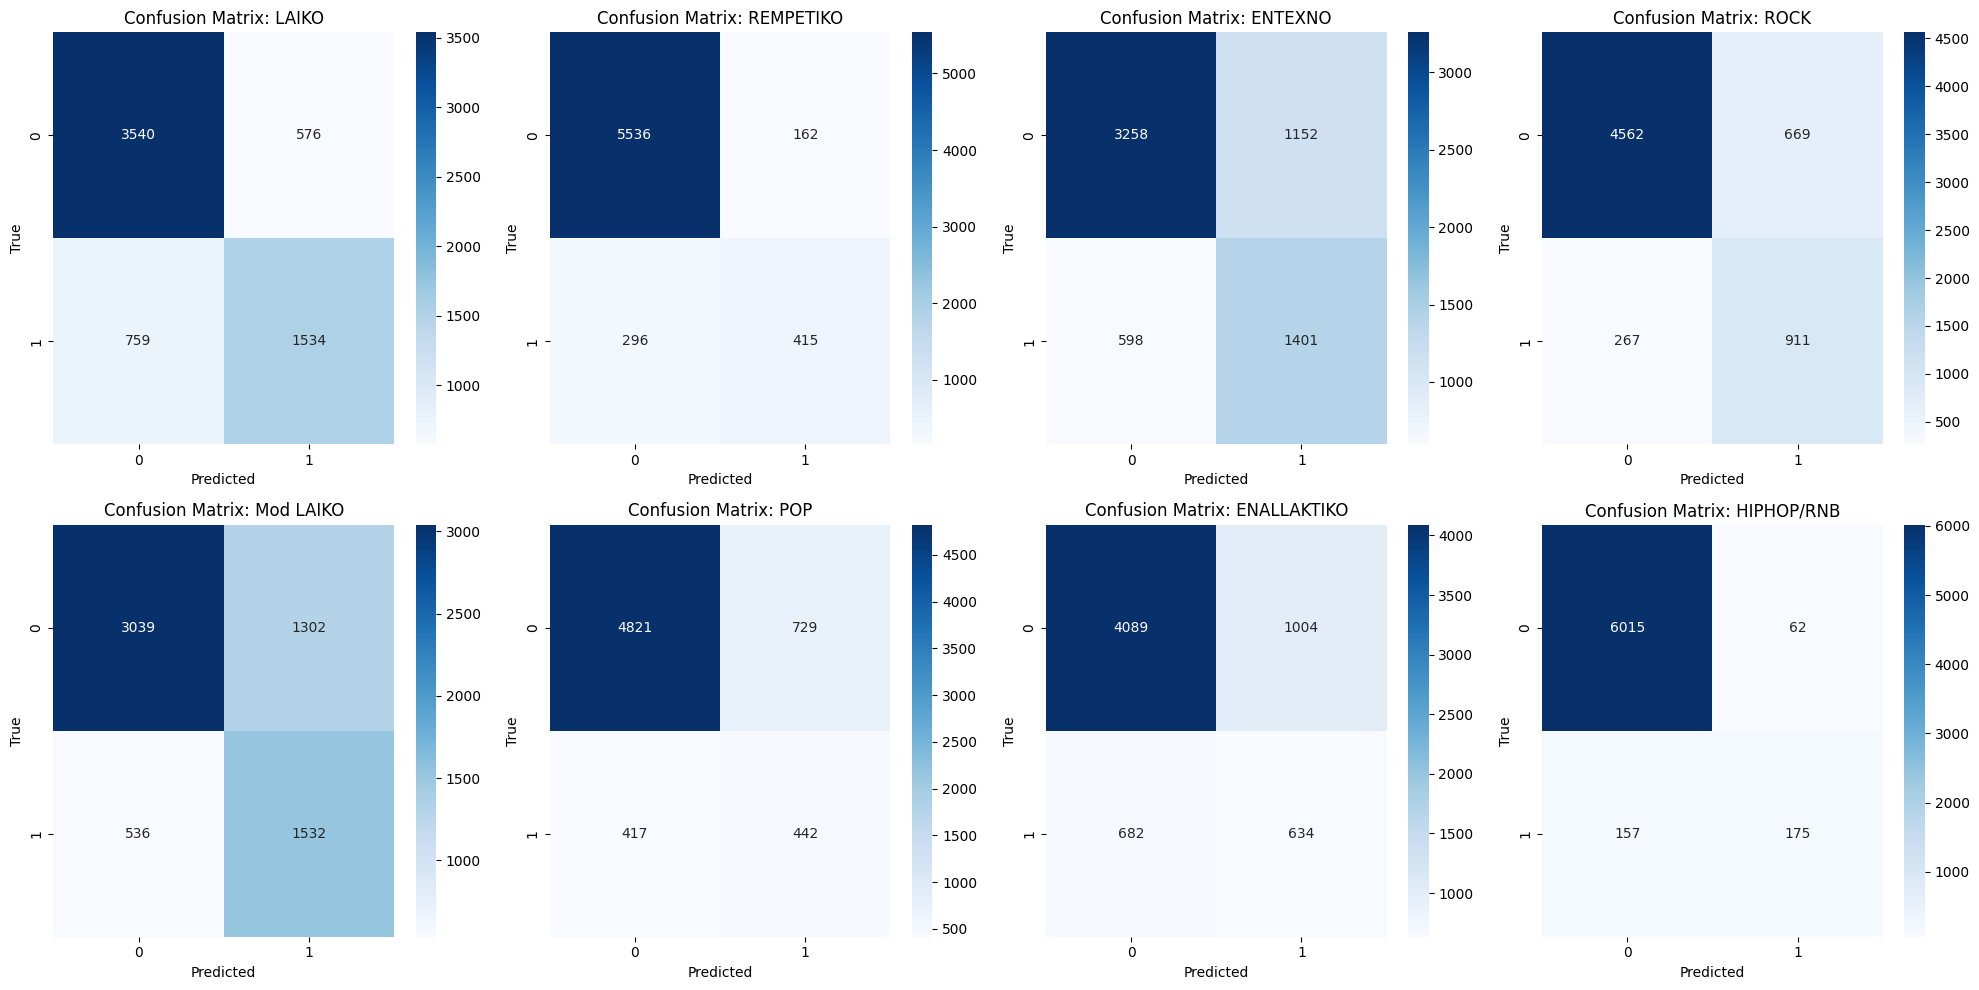

In [61]:
# Visualize results
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plot confusion matrix for each genre
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
cms = []

for i, (genre, ax) in enumerate(zip(genre_names, axes)):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i])
    cms.append(cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix: {genre}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    
plt.tight_layout()
plt.show();

In [62]:
y_true.shape

(6409, 8)

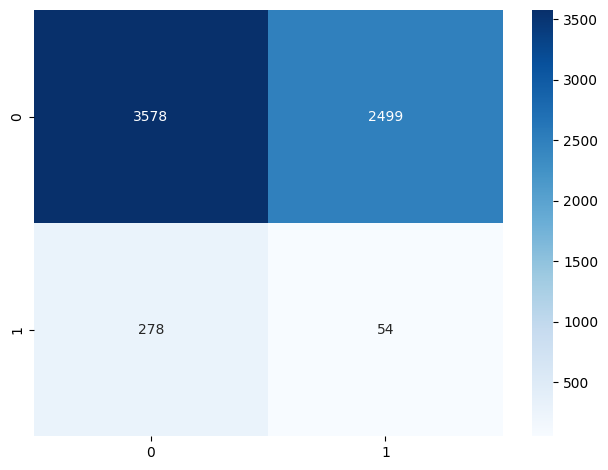

In [63]:
cm = tf.math.confusion_matrix(y_true[:,7], y_pred[:,2])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
ax.set_title(f'Confusion Matrix: {genre}')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout() 
plt.show();

In [64]:
for cm in cms:
    print(cm)

[[3540  576]
 [ 759 1534]]
[[5536  162]
 [ 296  415]]
[[3258 1152]
 [ 598 1401]]
[[4562  669]
 [ 267  911]]
[[3039 1302]
 [ 536 1532]]
[[4821  729]
 [ 417  442]]
[[4089 1004]
 [ 682  634]]
[[6015   62]
 [ 157  175]]


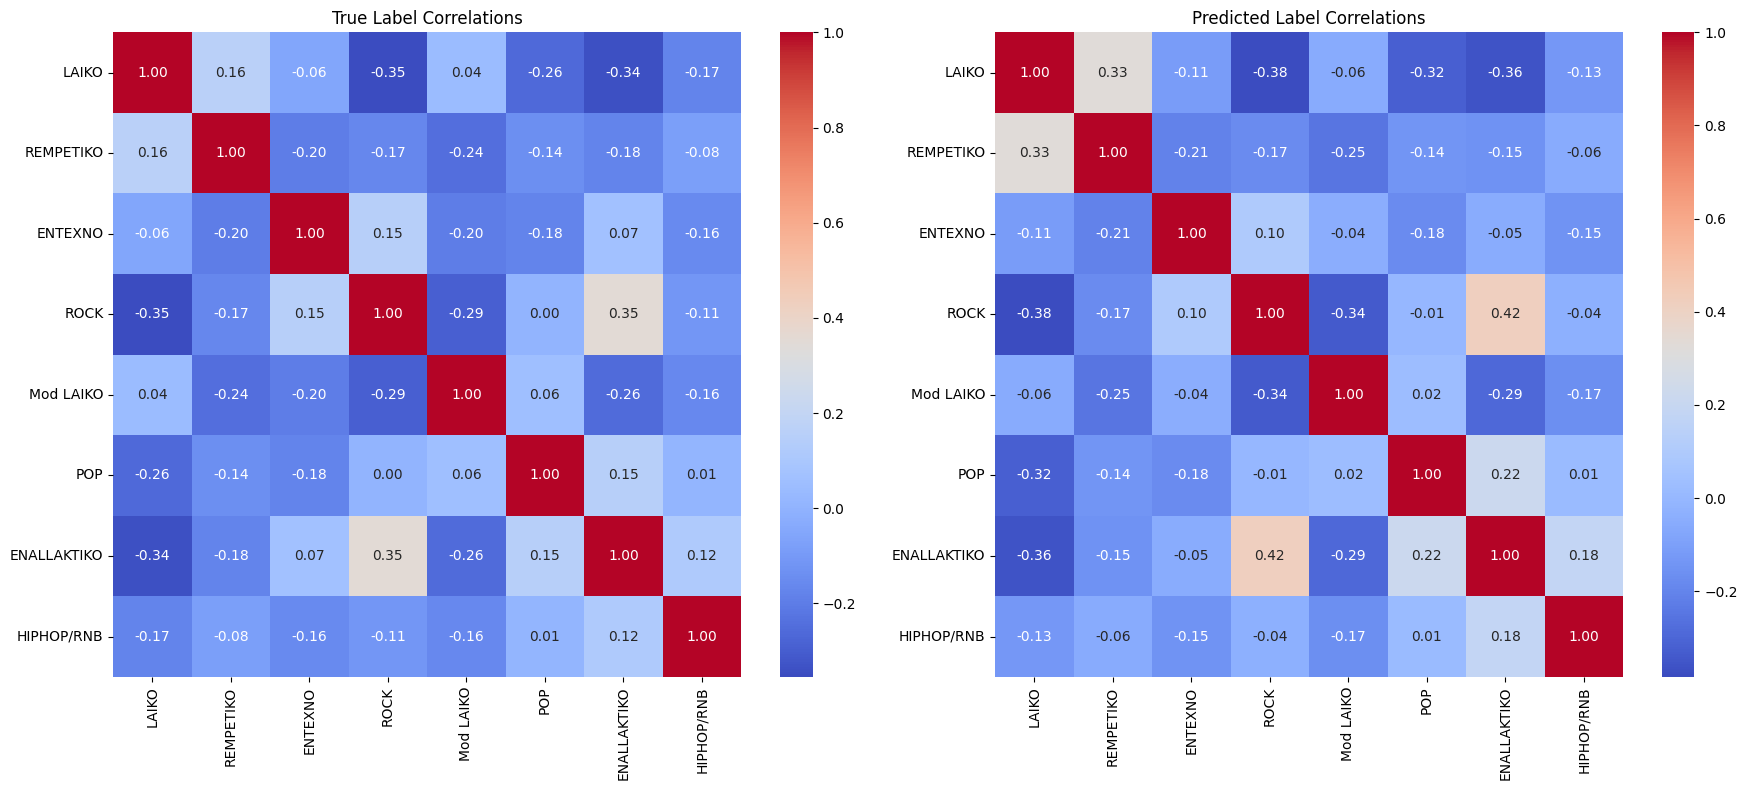

In [65]:
# correlation matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(true_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax1, 
            xticklabels=genre_names, yticklabels=genre_names)
ax1.set_title('True Label Correlations')

sns.heatmap(pred_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax2, 
            xticklabels=genre_names, yticklabels=genre_names)
ax2.set_title('Predicted Label Correlations')

plt.tight_layout()
plt.show();

In [94]:
# Create a new model that outputs only the dense embeddings
embedding_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer("aux_out").output)

# Get the embeddings
dense_embeddings = embedding_model.predict(test_dataset, batch_size=64)

201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


/home/georgios/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [95]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Run t-SNE (may take a minute)
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
tsne_results = TSNE(n_components=2, perplexity=30).fit_transform(dense_embeddings)

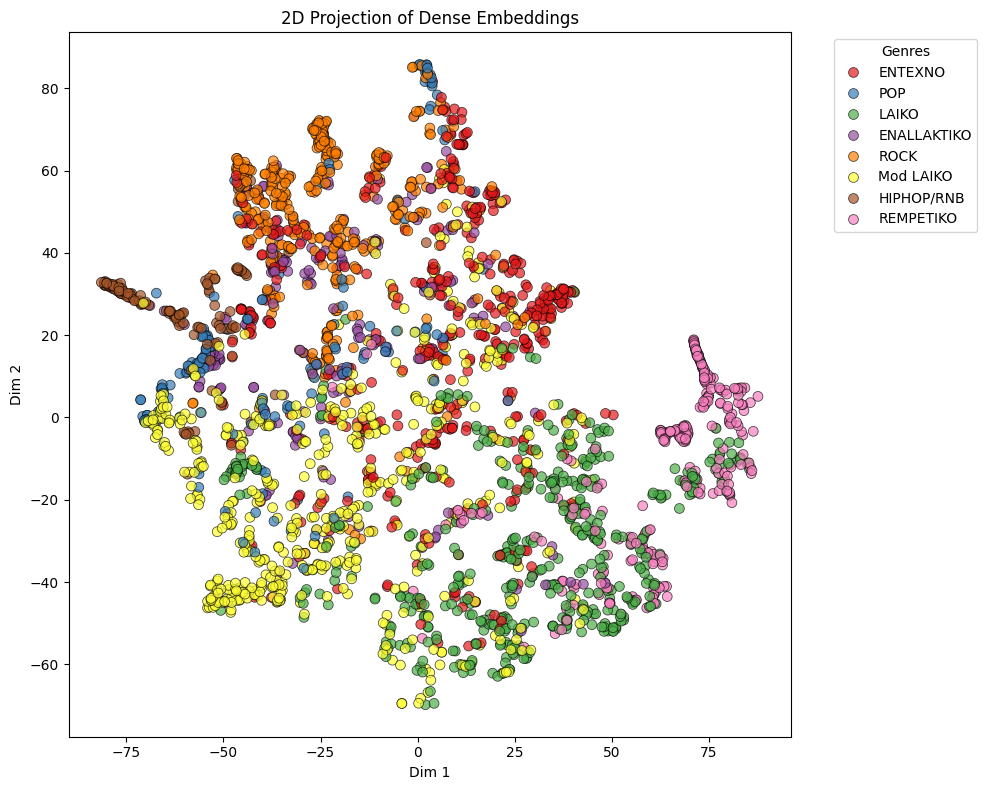

In [96]:
# Get most prominent label for coloring with argmax
single_label_mask = np.sum(y_true, axis=1) == 1
x_embedded_filtered = tsne_results[single_label_mask]
y_labels = np.argmax(y_true[single_label_mask], axis=1)

plt.figure(figsize=(10, 8))
palette = sns.color_palette("hsv", len(np.unique(y_labels)))

genre_names = ['LAIKO', 'REMPETIKO', 'ENTEXNO', 'ROCK', 'Mod LAIKO', 'POP', 'ENALLAKTIKO', 'HIPHOP/RNB']
y_labels_named = [genre_names[i] for i in y_labels]

sns.scatterplot(
    x=x_embedded_filtered[:, 0],
    y=x_embedded_filtered[:, 1],
    hue=y_labels_named,
    palette="Set1",  # updated for better color contrast
    alpha=0.7,
    s=50,
    edgecolor='k'
)


plt.title("2D Projection of Dense Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend(title="Genres", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()